We could explore vision transformers as there is no pre-trained vision transformer models in keras, and it would be something neat to explore

In [1]:
import os

# os.environ["KERAS_BACKEND"] = "jax"  # @param ["tensorflow", "jax", "torch"]

import keras
from keras import layers
from keras import ops

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

2026-04-15 17:21:04.497470: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776270064.524516  267208 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776270064.536156  267208 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776270064.636583  267208 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776270064.636658  267208 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776270064.636662  267208 computation_placer.cc:177] computation placer alr

In [2]:
gpus = tf.config.list_physical_devices('GPU')
gpus

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [3]:
# 16GB Tesla T4 (Google Colab)
# 4GB RTX 3050 Ti Laptop (Afonso)
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)
    tf.config.set_logical_device_configuration(
        gpu,
        [tf.config.LogicalDeviceConfiguration(memory_limit=round(3.8*1024))]
    )

# keras.mixed_precision.set_global_policy('mixed_float16')

## Data import

In [4]:
DATA_PATH = "../data"

image_size = (512, 512)
patch_size = 32
batch_size = 4
n_classes = 23

train_ds, val_ds = keras.utils.image_dataset_from_directory(
    DATA_PATH,
    image_size=image_size,
    batch_size=batch_size,
    seed=255, # for reproducibility
    validation_split=0.2,
    subset="both",
    label_mode="categorical"
)

Found 13340 files belonging to 23 classes.
Using 10672 files for training.
Using 2668 files for validation.


I0000 00:00:1776270070.847600  267208 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3891 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Ti Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


## Vanilla ViT - https://keras.io/examples/vision/image_classification_with_vision_transformer/

In [5]:
num_patches = (image_size[0] // patch_size) ** 2
projection_dim = 64
num_heads = 4
transformer_units = [
    projection_dim * 2,
    projection_dim,
]  # Size of the transformer layers
transformer_layers = 8
mlp_head_units = [
    2048,
    1024,
]

In [6]:
class Patches(layers.Layer):
    def __init__(self, patch_size):
        super().__init__()
        self.patch_size = patch_size

    def call(self, images):
        input_shape = ops.shape(images)
        batch_size = input_shape[0]
        height = input_shape[1]
        width = input_shape[2]
        channels = input_shape[3]
        num_patches_h = height // self.patch_size
        num_patches_w = width // self.patch_size
        patches = keras.ops.image.extract_patches(images, size=self.patch_size)
        patches = ops.reshape(
            patches,
            (
                batch_size,
                num_patches_h * num_patches_w,
                self.patch_size * self.patch_size * channels,
            ),
        )
        return patches

    def get_config(self):
        config = super().get_config()
        config.update({"patch_size": self.patch_size})
        return config

2026-04-15 17:21:13.344866: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
I0000 00:00:1776270073.668658  267208 cuda_dnn.cc:529] Loaded cuDNN version 91002


Image size: (512, 512) X (512, 512)
Patch size: 32 X 32
Patches per image: 256
Elements per patch: 3072


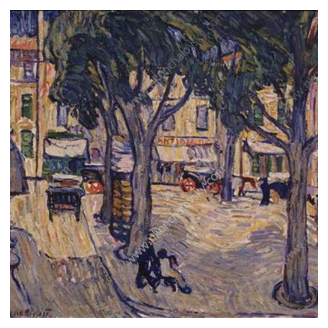

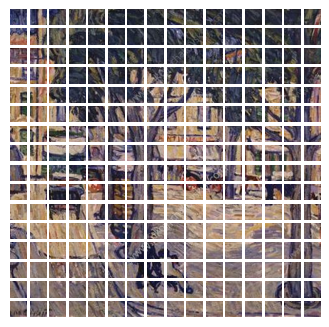

In [7]:
plt.figure(figsize=(4, 4))
image = list(train_ds.take(1).as_numpy_iterator())[0][0][0]
plt.imshow(image.astype("uint8"))
plt.axis("off")

resized_image = ops.image.resize(
    ops.convert_to_tensor([image]), size=(image_size[0], image_size[1])
)
patches = Patches(patch_size)(resized_image)
print(f"Image size: {image_size} X {image_size}")
print(f"Patch size: {patch_size} X {patch_size}")
print(f"Patches per image: {patches.shape[1]}")
print(f"Elements per patch: {patches.shape[-1]}")

n = int(np.sqrt(patches.shape[1]))
plt.figure(figsize=(4, 4))
for i, patch in enumerate(patches[0]):
    ax = plt.subplot(n, n, i + 1)
    patch_img = ops.reshape(patch, (patch_size, patch_size, 3))
    plt.imshow(ops.convert_to_numpy(patch_img).astype("uint8"))
    plt.axis("off")


In [8]:
class PatchEncoder(layers.Layer):
    def __init__(self, num_patches, projection_dim):
        super().__init__()
        self.num_patches = num_patches
        self.projection = layers.Dense(units=projection_dim)
        self.position_embedding = layers.Embedding(
            input_dim=num_patches, output_dim=projection_dim
        )

    def call(self, patch):
        positions = ops.expand_dims(
            ops.arange(start=0, stop=self.num_patches, step=1), axis=0
        )
        projected_patches = self.projection(patch)
        encoded = projected_patches + self.position_embedding(positions)
        return encoded

    def get_config(self):
        config = super().get_config()
        config.update({"num_patches": self.num_patches})
        return config

In [9]:
def mlp(x, hidden_units, dropout_rate):
    for units in hidden_units:
        x = layers.Dense(units, activation=keras.activations.gelu)(x)
        x = layers.Dropout(dropout_rate)(x)
    return x

In [10]:
def create_vit_classifier():
    inputs = keras.Input(shape=image_size + (3,))
    # Augment data.
    # augmented = data_augmentation(inputs)
    # Create patches.
    patches = Patches(patch_size)(inputs)
    # Encode patches.
    encoded_patches = PatchEncoder(num_patches, projection_dim)(patches)

    # Create multiple layers of the Transformer block.
    for _ in range(transformer_layers):
        # Layer normalization 1.
        x1 = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
        # Create a multi-head attention layer.
        attention_output = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=projection_dim, dropout=0.1
        )(x1, x1)
        # Skip connection 1.
        x2 = layers.Add()([attention_output, encoded_patches])
        # Layer normalization 2.
        x3 = layers.LayerNormalization(epsilon=1e-6)(x2)
        # MLP.
        x3 = mlp(x3, hidden_units=transformer_units, dropout_rate=0.1)
        # Skip connection 2.
        encoded_patches = layers.Add()([x3, x2])

    # Create a [batch_size, projection_dim] tensor.
    representation = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
    representation = layers.Flatten()(representation)
    representation = layers.Dropout(0.5)(representation)
    # Add MLP.
    features = mlp(representation, hidden_units=mlp_head_units, dropout_rate=0.5)
    # Classify outputs.
    logits = layers.Dense(n_classes)(features)
    # Create the Keras model.
    model = keras.Model(inputs=inputs, outputs=logits)
    return model

In [13]:
def run_experiment(model):
    optimizer = keras.optimizers.Adam(
        learning_rate=1e-4,
    )

    model.compile(
        optimizer=optimizer,
        loss=keras.losses.CategoricalCrossentropy(),
        metrics=[
            keras.metrics.CategoricalAccuracy(name="accuracy"),
            # keras.metrics.TopKCategoricalAccuracy(5, name="top-5-accuracy"),
            keras.metrics.F1Score(average="macro", name="f1_score")
        ],
    )

    # checkpoint_filepath = "/tmp/checkpoint.weights.h5"
    # checkpoint_callback = keras.callbacks.ModelCheckpoint(
    #     checkpoint_filepath,
    #     monitor="val_accuracy",
    #     save_best_only=True,
    #     save_weights_only=True,
    # )

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        batch_size=batch_size,
        epochs=10,
        # callbacks=[checkpoint_callback],
    )

    # model.load_weights(checkpoint_filepath)
    # _, accuracy, top_5_accuracy = model.evaluate(x_test, y_test)
    # print(f"Test accuracy: {round(accuracy * 100, 2)}%")
    # print(f"Test top 5 accuracy: {round(top_5_accuracy * 100, 2)}%")

    return history


vit_classifier = create_vit_classifier()
history = run_experiment(vit_classifier)


def plot_history(item):
    plt.plot(history.history[item], label=item)
    plt.plot(history.history["val_" + item], label="val_" + item)
    plt.xlabel("Epochs")
    plt.ylabel(item)
    plt.title("Train and Validation {} Over Epochs".format(item), fontsize=14)
    plt.legend()
    plt.grid()
    plt.show()


plot_history("loss")
plot_history("top-5-accuracy")


Epoch 1/10
2668/2668 ━━━━━━━━━━━━━━━━━━━━ 171s 45ms/step - accuracy: 0.0632 - f1_score: 0.0269 - loss: 8.0099 - val_accuracy: 0.1001 - val_f1_score: 0.0079 - val_loss: 7.3401
Epoch 2/10
2668/2668 ━━━━━━━━━━━━━━━━━━━━ 114s 43ms/step - accuracy: 0.0669 - f1_score: 0.0292 - loss: 8.1614 - val_accuracy: 0.1001 - val_f1_score: 0.0079 - val_loss: 8.7779
Epoch 3/10
2668/2668 ━━━━━━━━━━━━━━━━━━━━ 114s 43ms/step - accuracy: 0.0566 - f1_score: 0.0281 - loss: 8.0658 - val_accuracy: 0.0731 - val_f1_score: 0.0059 - val_loss: 8.7779
Epoch 4/10
2668/2668 ━━━━━━━━━━━━━━━━━━━━ 523s 196ms/step - accuracy: 0.0549 - f1_score: 0.0282 - loss: 8.1444 - val_accuracy: 0.1001 - val_f1_score: 0.0079 - val_loss: 8.7779
Epoch 5/10
 220/2668 ━━━━━━━━━━━━━━━━━━━━ 16:42 410ms/step - accuracy: 0.0459 - f1_score: 0.0187 - loss: 8.4526

KeyboardInterrupt: 

## Dynamic Hybrid Vision Transformer - https://arxiv.org/abs/2210.05958

Vanilla ViTs need lots of data to learn to take into consideration neighboring tokens, so now we will explore this paper that introduces some new concepts that aim to help ViTs to be trained on small datasets such as ours:
- concept 1...